
# Lab 02 — Simple Gradient Descent (Linear Regression)

This lab walks through:
1) Generating synthetic linear data  
2) Implementing gradient descent for a line \( y = m x + b \) using MSE  
3) Understanding the effect of the **learning rate**  
4) Seeing **batch**, **stochastic (SGD)**, and **mini-batch** gradient descent


## 1. Generating Synthetic Data

To begin, we create a simple dataset that roughly follows a straight line. This will help us understand how gradient descent works in a controlled setting.

- We generate **100 random values** of $X$ uniformly between 0 and 2.  
- We define the target values $y$ using a true linear relationship:

$$
y = 5 + 2x + \text{noise}
$$

Here:
- The slope (true $m$) = 2  
- The intercept (true $b$) = 5  
- Some random Gaussian noise is added to make the data more realistic.

Finally, we plot the dataset to visualize the points. The data should appear roughly linear with some scatter due to noise.



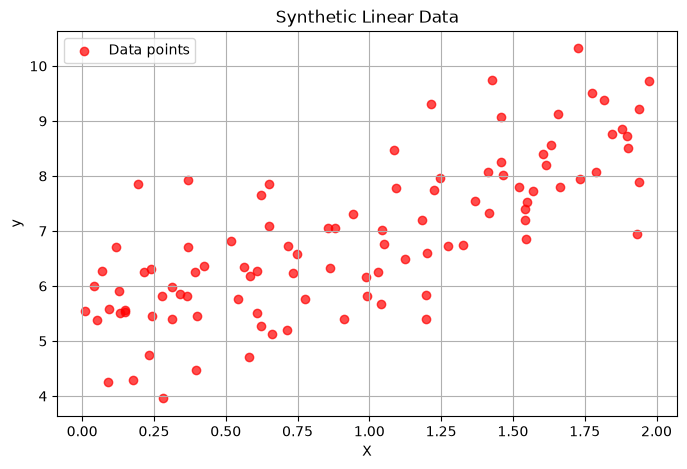

In [1]:

import numpy as np
import matplotlib.pyplot as plt

# Set the random seed for reproducibility so that every run generates the same random numbers
np.random.seed(42)

# Generate input feature values (X):
# - 100 random values between 0 and 2
# - Each value stored as a row vector (100 rows, 1 column)
X = 2 * np.random.rand(100, 1)

# Generate target values (y) from a linear function with noise:
# y = 5 + 2x + random noise
# - slope (m) = 2, intercept (b) = 5
# - noise makes the data more realistic (not a perfect line)
y = 5 + 2 * X + np.random.randn(100, 1)

# Visualize the synthetic dataset
plt.figure(figsize=(8, 5))
plt.scatter(X, y, color="red", alpha=0.7, label="Data points")
plt.title("Synthetic Linear Data")
plt.xlabel("X")
plt.ylabel("y")
plt.grid(True)
plt.legend()
plt.show()


## 2. Training a Linear Model with Batch Gradient Descent

Next, we train a simple linear regression model using **Batch Gradient Descent (BGD)**.  
The model tries to fit a straight line of the form “output = slope × input + intercept”.

### Steps:

1. **Parameter Initialization**  
   - Start with random values for slope (m) and intercept (b).

2. **Set Hyperparameters**  
   - Learning rate controls how big each adjustment step is.  
   - Epochs decide how many times we repeat the process.

3. **Loss Function**  
   - We measure how far predictions are from the true values using **Mean Squared Error (MSE)**.  
   - The smaller the loss, the better our line fits the data.

4. **Gradient Computation**  
   - We calculate how much to change slope and intercept to reduce the loss.  
   - These changes tell us the “direction” of improvement.

5. **Parameter Update Rule**  
   - We adjust slope and intercept by taking a small step in the right direction.  
   - This process is repeated for many steps.

6. **Training Loop**  
   - At each iteration, we make predictions, calculate loss, update parameters, and track progress.

### Visualization:
- We plot the **loss curve** to see how the error decreases over time.  
- Finally, we plot the **best-fit line** learned by gradient descent over the original dataset.


Starting parameters: m = 0.0130, b = 1.4535
Epoch 10/100, Loss: 1.0588
Epoch 20/100, Loss: 0.9320
Epoch 30/100, Loss: 0.8694
Epoch 40/100, Loss: 0.8381
Epoch 50/100, Loss: 0.8224
Epoch 60/100, Loss: 0.8145
Epoch 70/100, Loss: 0.8106
Epoch 80/100, Loss: 0.8086
Epoch 90/100, Loss: 0.8076
Epoch 100/100, Loss: 0.8071

Final learned parameters: m = 1.8048, b = 5.1758


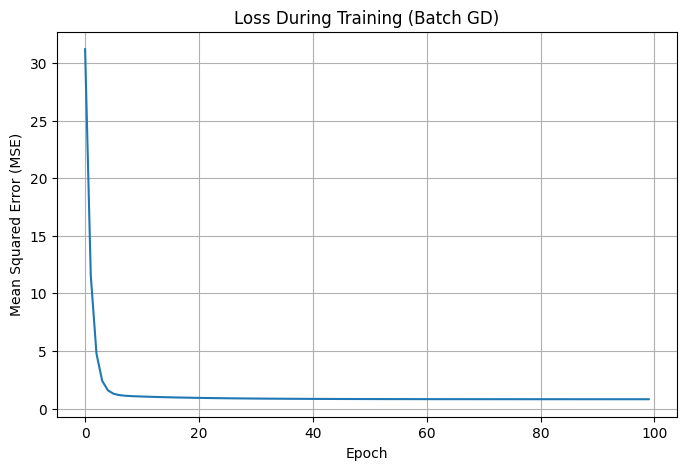

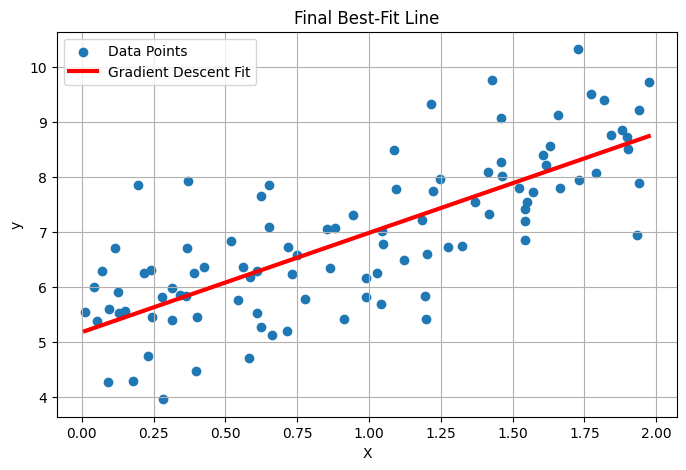

In [9]:
# -------------------------------------------------------
# Initialize model parameters (weights) with random values
# -------------------------------------------------------
# m = slope, b = intercept for the line y = mx + b
m = np.random.randn()
b = np.random.randn()

# -------------------------------------------------------
# Set hyperparameters
# -------------------------------------------------------
learning_rate = 0.1   # Step size for updating parameters
epochs = 100          # Number of iterations through the full dataset

# -------------------------------------------------------
# Variables to track training progress
# -------------------------------------------------------
loss_history = []     # Store loss values to visualize later
n_samples = len(X)    # Total number of data points

print(f"Starting parameters: m = {m:.4f}, b = {b:.4f}")

# -------------------------------------------------------
# Training loop — Gradient Descent
# -------------------------------------------------------
for i in range(epochs):
    # Step 1: Predictions with current parameters
    y_pred = m * X + b

    # Step 2: Compute the loss using Mean Squared Error (MSE)
    loss = np.mean((y - y_pred)**2)
    loss_history.append(loss)

    # Step 3: Compute gradients (derivatives of MSE w.r.t. m and b)
    # dm = partial derivative of loss w.r.t. m
    # db = partial derivative of loss w.r.t. b
    dm = (-2/n_samples) * np.sum(X * (y - y_pred))
    db = (-2/n_samples) * np.sum(y - y_pred)

    # Step 4: Update parameters using the gradient descent rule
    m = m - learning_rate * dm
    b = b - learning_rate * db

    # Step 5: Print progress every 10 epochs
    if (i+1) % 10 == 0:
        print(f"Epoch {i+1}/{epochs}, Loss: {loss:.4f}")

# -------------------------------------------------------
# After training
# -------------------------------------------------------
print(f"\nFinal learned parameters: m = {m:.4f}, b = {b:.4f}")

# -------------------------------------------------------
# Plot how the loss decreased over time
# -------------------------------------------------------
plt.figure(figsize=(8, 5))
plt.plot(range(epochs), loss_history)
plt.title("Loss During Training (Batch GD)")
plt.xlabel("Epoch")
plt.ylabel("Mean Squared Error (MSE)")
plt.grid(True)
plt.show()

# -------------------------------------------------------
# Plot the final line fit against the data
# -------------------------------------------------------
plt.figure(figsize=(8, 5))
plt.scatter(X, y, label='Data Points')

# Sort X for plotting a smooth line (instead of scattered line segments)
order = np.argsort(X[:,0])
X_sorted = X[order]
y_line = m * X_sorted + b

plt.plot(X_sorted, y_line, color="red", linewidth=3, label='Gradient Descent Fit')
plt.title("Final Best-Fit Line")
plt.xlabel("X")
plt.ylabel("y")
plt.legend()
plt.grid(True)
plt.show()


## 3. Effect of Learning Rate on Gradient Descent

The **learning rate** ($\alpha$) controls the step size in gradient descent updates.  
Choosing $\alpha$ too large or too small can drastically change the behavior of training.

### Case 1: Large Learning Rate (Divergence)

When the learning rate is too high (e.g., $\alpha = 0.5$), updates overshoot the minimum.  
Instead of converging, the loss oscillates or even increases:
- Large steps cause the model to "zigzag" across the loss surface.  
- The Mean Squared Error (MSE) does not decrease and may diverge.  
- The loss curve shows instability rather than smooth convergence.

### Case 2: Small Learning Rate (Slow Convergence)

When the learning rate is too low (e.g., $\alpha = 0.001$), the model learns very slowly.

- Updates are so small that it takes many epochs to reduce the loss.  
- Convergence is stable, but inefficient.  
- The loss decreases steadily but much more slowly compared to an optimal learning rate.

### Takeaway:
- **Too large $\alpha$** → divergence (loss increases).  
- **Too small $\alpha$** → very slow convergence.  
- **A good $\alpha$** (e.g., 0.05 in our case) leads to stable and fast convergence.


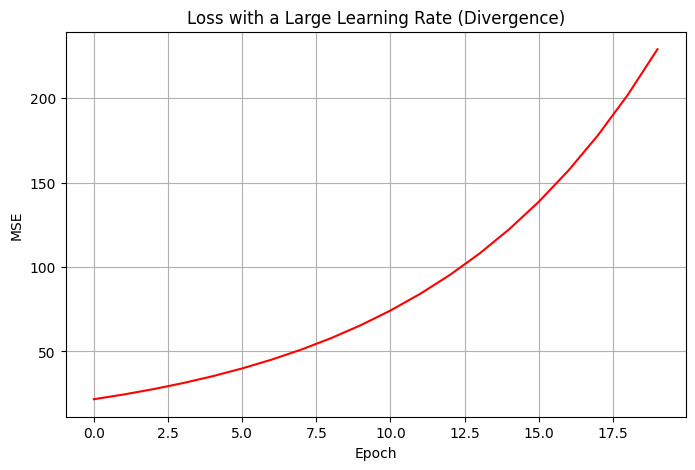

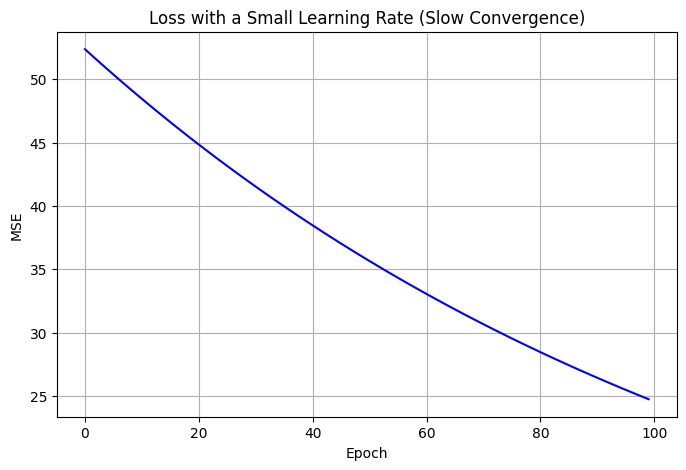

In [10]:
# -------------------------------------------------------
# Case 1: Divergence with a large learning rate
# -------------------------------------------------------
# Re-initialize parameters randomly
m, b = np.random.randn(), np.random.randn()

# Use a much larger learning rate
large_lr = 0.5
large_lr_loss = []

# Run only a few epochs to demonstrate instability
for i in range(20):
    # Predictions with current parameters
    y_pred = m * X + b
    
    # Calculate loss (MSE)
    loss = np.mean((y - y_pred)**2)
    large_lr_loss.append(loss)
    
    # Compute gradients
    dm = (-2/n_samples) * np.sum(X * (y - y_pred))
    db = (-2/n_samples) * np.sum(y - y_pred)
    
    # Update parameters with large steps
    # -> Too big a step can overshoot the minimum,
    #    causing the loss to increase (divergence).
    m = m - large_lr * dm
    b = b - large_lr * db

# Plot loss curve for large learning rate
plt.figure(figsize=(8, 5))
plt.plot(large_lr_loss, color="red")
plt.title("Loss with a Large Learning Rate (Divergence)")
plt.xlabel("Epoch")
plt.ylabel("MSE")
plt.grid(True)
plt.show()


# -------------------------------------------------------
# Case 2: Slow convergence with a small learning rate
# -------------------------------------------------------
# Re-initialize parameters randomly again
m, b = np.random.randn(), np.random.randn()

# Use a very small learning rate
small_lr = 0.001
small_lr_loss = []

# Run more epochs (100) to show slow but steady progress
for i in range(100):
    # Predictions
    y_pred = m * X + b
    
    # Loss (MSE)
    loss = np.mean((y - y_pred)**2)
    small_lr_loss.append(loss)
    
    # Gradients
    dm = (-2/n_samples) * np.sum(X * (y - y_pred))
    db = (-2/n_samples) * np.sum(y - y_pred)
    
    # Update parameters with tiny steps
    # -> Converges safely but requires many iterations
    m = m - small_lr * dm
    b = b - small_lr * db

# Plot loss curve for small learning rate
plt.figure(figsize=(8, 5))
plt.plot(small_lr_loss, color="blue")
plt.title("Loss with a Small Learning Rate (Slow Convergence)")
plt.xlabel("Epoch")
plt.ylabel("MSE")
plt.grid(True)
plt.show()


## 4. Batch vs. Stochastic vs. Mini-batch Gradient Descent

So far, we have used Batch Gradient Descent, where the model looks at **all data points** to update the parameters in each step.  
In practice, there are different ways to estimate the gradient, each with its own trade-offs.

### Methods

- **Batch Gradient Descent (BGD)**  
  - Uses the **entire dataset** in every update step.  
  - Very **stable** and smooth learning curve.  
  - Can be slow if the dataset is very large, since each update is expensive.

- **Stochastic Gradient Descent (SGD)**  
  - Uses **only one random sample** for each update.  
  - Makes updates very fast, but the learning curve is **noisy**.  
  - Often jumps around but can still reach a good solution.

- **Mini-batch Gradient Descent**  
  - Uses a **small group of random samples** for each update (e.g., 16 or 32).  
  - A good balance: less noisy than pure SGD, but faster and more efficient than full batch.  
  - This is the most common method used in practice (especially for deep learning).

### What to look for in the plot
- **Batch GD (blue, dashed):** smooth and stable curve.  
- **SGD (orange):** noisy curve that zigzags but still improves.  
- **Mini-batch (green):** somewhere in between—stable enough but also efficient.  

**Takeaway:** The choice of batch size affects how smooth or noisy the training process looks, and how quickly we reach a good solution.


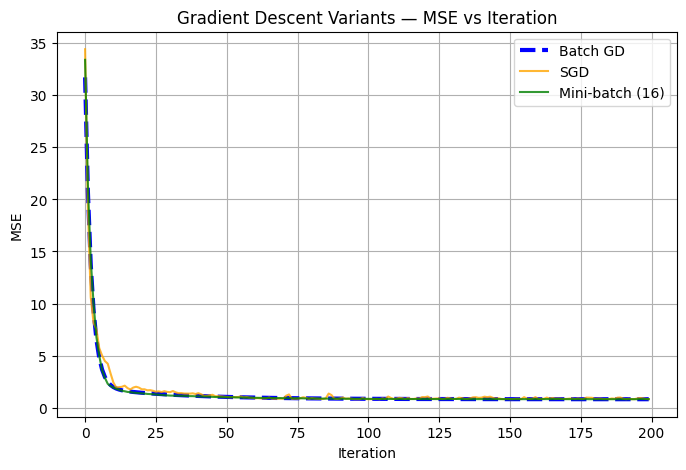

In [11]:
# -------------------------------------------------------
# Batch Gradient Descent (uses the whole dataset each step)
# -------------------------------------------------------
def run_batch_gd(X, y, lr=0.05, iters=200):
    # Initialize parameters (slope m, intercept b)
    m, b = 0.0, 0.0
    n = len(X)           # number of samples
    losses = []          # to record full-dataset MSE per iteration

    for t in range(iters):
        # Predictions for ALL points (vectorized)
        # X has shape (n, 1), so m * X broadcasts to (n, 1)
        y_pred = m * X + b

        # Gradients of MSE w.r.t. m and b (batch = whole dataset)
        # dm, db are scalars because m and b are scalars
        dm = (-2/n) * np.sum(X * (y - y_pred))
        db = (-2/n) * np.sum(y - y_pred)

        # Parameter updates: w_new = w_old - lr * grad
        m -= lr * dm
        b -= lr * db

        # Track the full-dataset loss after the update (fair comparison)
        losses.append(np.mean((y - (m*X + b))**2))

    return m, b, np.array(losses)


# -------------------------------------------------------------------
# Stochastic Gradient Descent (updates using ONE random sample/step)
# -------------------------------------------------------------------
def run_sgd(X, y, lr=0.05, iters=200, seed=0):
    rng = np.random.default_rng(seed)
    m, b = 0.0, 0.0
    n = len(X)
    losses = []

    for t in range(iters):
        # Pick ONE random index (stochastic)
        i = rng.integers(0, n)
        x_i, y_i = X[i], y[i]   # shapes: (1,), (1,)

        # Prediction for that single point
        y_pred_i = m * x_i + b

        # Gradients from this single sample
        # Note: same formulas as batch but without averaging over n
        dm = -2 * x_i * (y_i - y_pred_i)
        db = -2 * (y_i - y_pred_i)

        # Noisy update (one sample drives the step)
        m -= lr * dm
        b -= lr * db

        # Track full-dataset MSE (so curves are comparable to batch/minibatch)
        losses.append(np.mean((y - (m*X + b))**2))

    return m, b, np.array(losses)


# -------------------------------------------------------------------------
# Mini-batch Gradient Descent (updates using a RANDOM subset per step)
# -------------------------------------------------------------------------
def run_minibatch_gd(X, y, lr=0.05, iters=200, batch_size=16, seed=0):
    rng = np.random.default_rng(seed)
    m, b = 0.0, 0.0
    n = len(X)
    losses = []

    for t in range(iters):
        # Sample a mini-batch of indices WITHOUT replacement
        idx = rng.choice(n, size=batch_size, replace=False)
        Xb, yb = X[idx], y[idx]     # shapes: (batch_size, 1)

        # Predictions for the batch
        y_pred_b = m * Xb + b

        # Gradients averaged over the mini-batch
        dm = (-2/len(Xb)) * np.sum(Xb * (yb - y_pred_b))
        db = (-2/len(Xb)) * np.sum(yb - y_pred_b)

        # Update using the batch gradient estimate
        m -= lr * dm
        b -= lr * db

        # Track full-dataset MSE (consistent comparison across methods)
        losses.append(np.mean((y - (m*X + b))**2))

    return m, b, np.array(losses)


# -------------------------
# Run all three variants
# -------------------------
m_b, b_b, loss_batch = run_batch_gd(X, y, lr=0.05, iters=200)
m_s, b_s, loss_sgd   = run_sgd(X, y, lr=0.05, iters=200, seed=1)
m_m, b_m, loss_mini  = run_minibatch_gd(X, y, lr=0.05, iters=200, batch_size=16, seed=1)

# -------------------------
# Plot the loss trajectories
# -------------------------
plt.figure(figsize=(8, 5))
plt.plot(loss_batch, label="Batch GD", color="blue", linewidth=3, linestyle="--")  # smooth (low noise)
plt.plot(loss_sgd,   label="SGD",      color="orange", alpha=0.8)                  # noisy (per-sample)
plt.plot(loss_mini,  label="Mini-batch (16)", color="green", alpha=0.8)            # in-between
plt.title("Gradient Descent Variants — MSE vs Iteration")
plt.xlabel("Iteration")
plt.ylabel("MSE")
plt.legend()
plt.grid(True)
plt.show()
